In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from pandas.core.reshape.merge import merge
import plotly
import plotly.express as px
import plotly.graph_objs as go
from plotly.offline import init_notebook_mode, plot, iplot
from plotly import tools
from warnings import filterwarnings
filterwarnings('ignore')

ipl_matches=pd.read_csv("/kaggle/input/ipl-data-set/matches.csv")
ipl_deliveries=pd.read_csv("/kaggle/input/ipl-data-set/deliveries.csv")

*The Indian Premier League or IPL is a T20 cricket tournament organized annually by the Board of Control for Cricket In India (BCCI). Eight city-based franchises compete with each other over 6 weeks to find the winner.*
**I'm going to analyze data from the IPL's past seasons to see which teams have won the most games, how teams behave when winning a toss, who has the greatest legacy, and so on.**

In [2]:
ipl_matches.head()
# Taking the preview of the matches datset.

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN


In [3]:
ipl_deliveries.head()
# Preview of deliveries dataset.

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [4]:
ipl_matches.shape
# this will tell us the total no. of rows and columns in our dataset.

(636, 18)

In [5]:
ipl_deliveries.shape
# Total number of rows and columns in deliveries dataset.

(150460, 21)

In [6]:
ipl_matches.isnull().sum()

id                   0
season               0
city                 7
date                 0
team1                0
team2                0
toss_winner          0
toss_decision        0
result               0
dl_applied           0
winner               3
win_by_runs          0
win_by_wickets       0
player_of_match      3
venue                0
umpire1              1
umpire2              1
umpire3            636
dtype: int64

In [7]:
ipl_deliveries.isnull().sum()

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batsman                  0
non_striker              0
bowler                   0
is_super_over            0
wide_runs                0
bye_runs                 0
legbye_runs              0
noball_runs              0
penalty_runs             0
batsman_runs             0
extra_runs               0
total_runs               0
player_dismissed    143022
dismissal_kind      143022
fielder             145091
dtype: int64

In [8]:
ipl_matches["player_of_match"].value_counts()

player_of_match
CH Gayle          18
YK Pathan         16
DA Warner         15
AB de Villiers    15
RG Sharma         14
                  ..
AD Mathews         1
LR Shukla          1
R Bhatia           1
A Singh            1
BCJ Cutting        1
Name: count, Length: 201, dtype: int64

**Data Preparing and Cleaning**

In [9]:
matches_df = ipl_matches.drop(columns=['umpire3'])

In [10]:
matches_df.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN


In [11]:
deliveries_df = ipl_deliveries.drop(columns=['fielder', 'player_dismissed', 'dismissal_kind'])
# These columns have very much null values, so removing them from our table.

In [12]:
deliveries_df.head()

,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,is_super_over,wide_runs,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs
0,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0
1,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0
2,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,4,0,4
3,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,0,0,0,0,0,0,0,0,0
4,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,0,2,0,0,0,0,0,2,2


In [13]:
deliveries_df['match_id'].value_counts()

match_id
126    267
34     263
476    262
534    262
388    261
      ... 
100    123
120    108
568    106
452    100
301     63
Name: count, Length: 636, dtype: int64

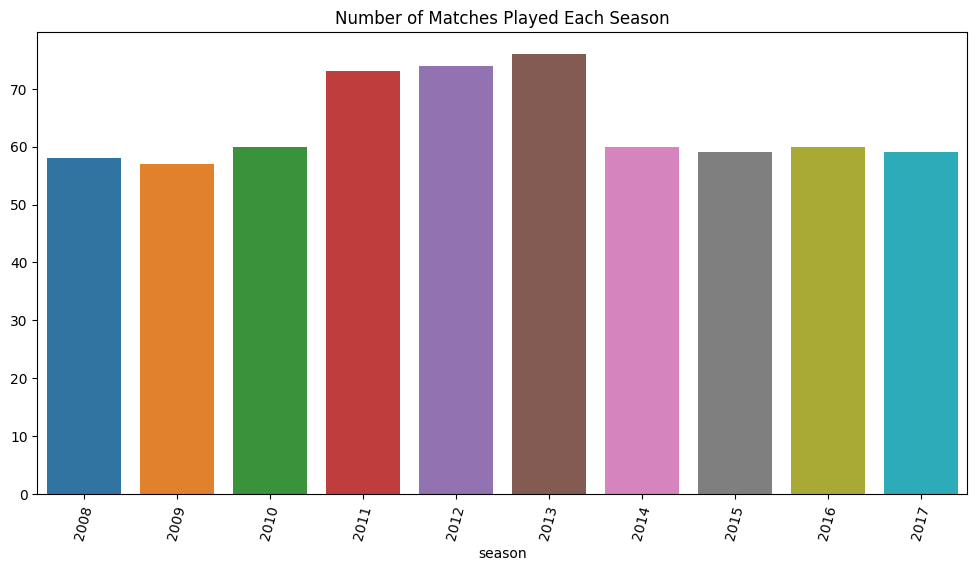

In [14]:
# Number of matches per season
matches_per_season = matches_df.groupby('season')['id'].count()
plt.figure(figsize=(12, 6))
sns.barplot(x=matches_per_season.index, y=matches_per_season.values)
plt.xticks(rotation=75)
plt.title('Number of Matches Played Each Season')
plt.show()

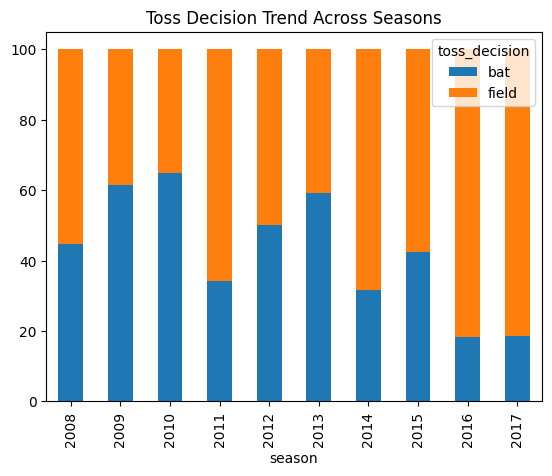

In [15]:
# ANALYZING THE TOSS RESULTS
toss_decision_percentage = (matches_df.groupby(['season', 'toss_decision']).size() / matches_per_season) * 100
toss_decision_percentage = toss_decision_percentage.unstack().plot(kind='bar', stacked=True)
plt.title('Toss Decision Trend Across Seasons')
plt.show()


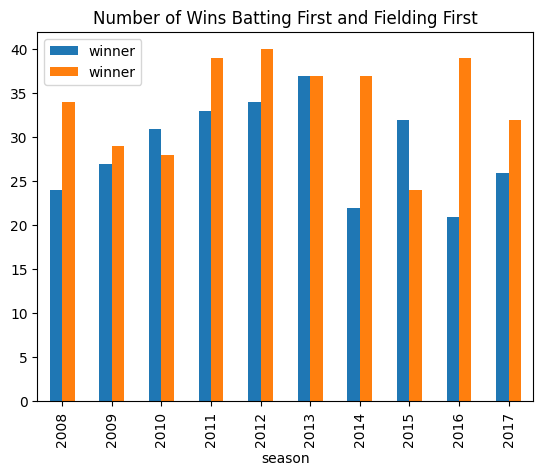

In [16]:
# NUMBER OF WINS
wins_batting_first = matches_df[(matches_df['win_by_wickets'] == 0) & (matches_df['result'] == 'normal')].groupby('season')['winner'].count()
wins_fielding_first = matches_df[(matches_df['win_by_runs'] == 0) & (matches_df['result'] == 'normal')].groupby('season')['winner'].count()

# Combine the two series
combined_wins_df = pd.concat([wins_batting_first, wins_fielding_first], axis=1)
combined_wins_df.plot(kind='bar')
plt.title('Number of Wins Batting First and Fielding First')
plt.show()

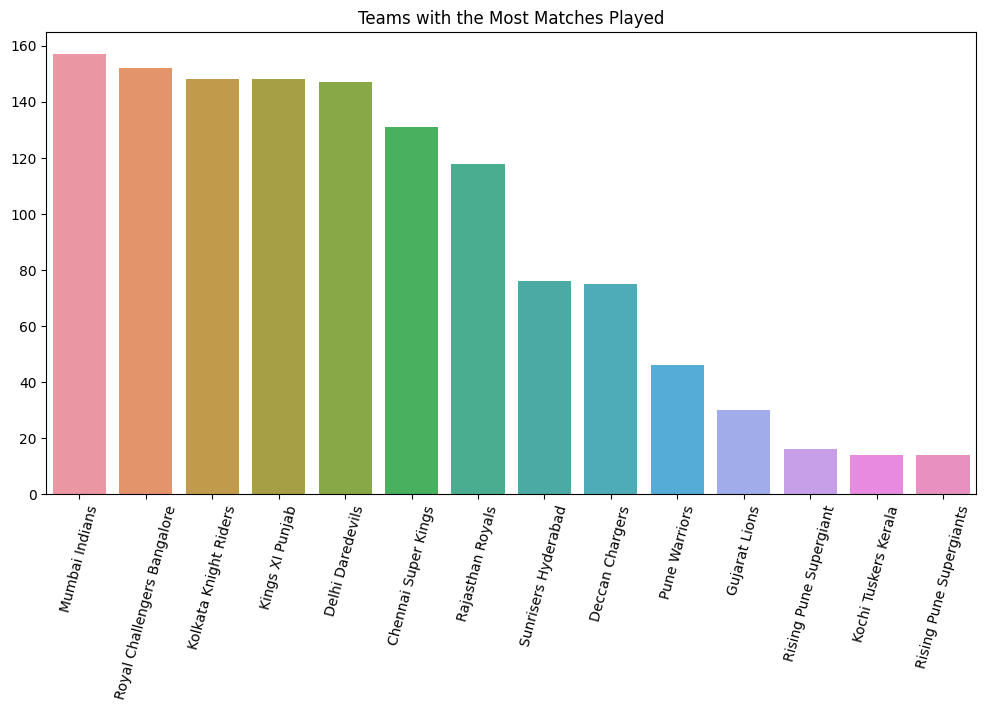

In [17]:
# TEAM WITH "HISTORY"
teams_with_most_matches = pd.concat([matches_df['team1'], matches_df['team2']]).value_counts().sort_values(ascending=False)
plt.figure(figsize=(12, 6))
sns.barplot(x=teams_with_most_matches.index, y=teams_with_most_matches.values)
plt.xticks(rotation=75)
plt.title('Teams with the Most Matches Played')
plt.show()

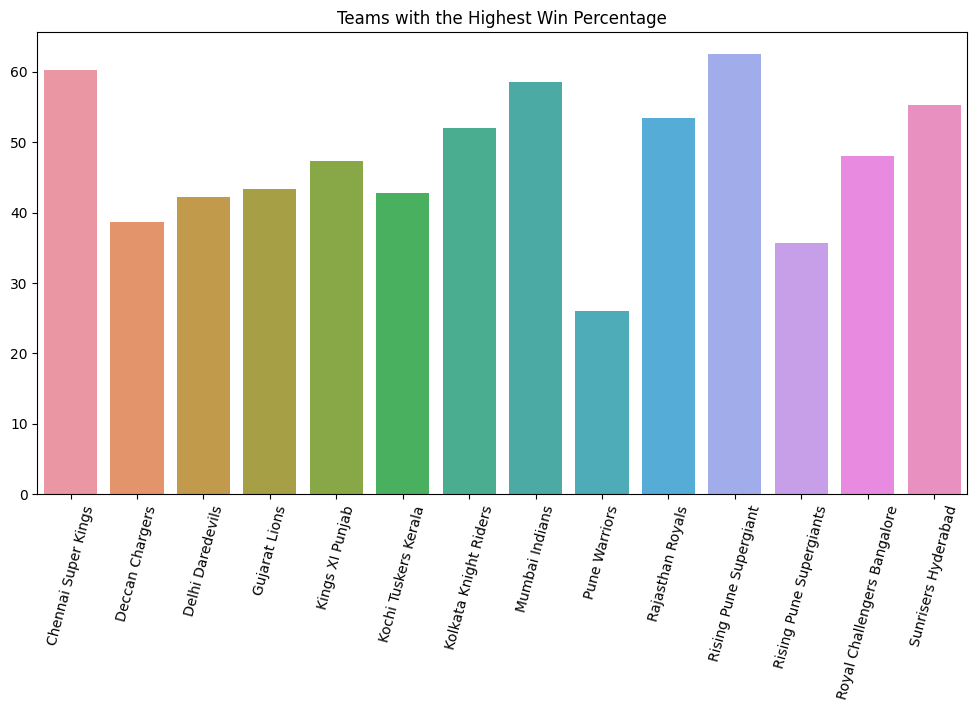

In [18]:
# TEAM WITH "LEGACY"
most_wins = matches_df['winner'].value_counts()
total_matches_played = pd.concat([matches_df['team1'], matches_df['team2']]).value_counts()
win_percentage = (most_wins / total_matches_played) * 100
plt.figure(figsize=(12, 6))
sns.barplot(x=win_percentage.index, y=win_percentage.values)
plt.xticks(rotation=75)
plt.title('Teams with the Highest Win Percentage')
plt.show()

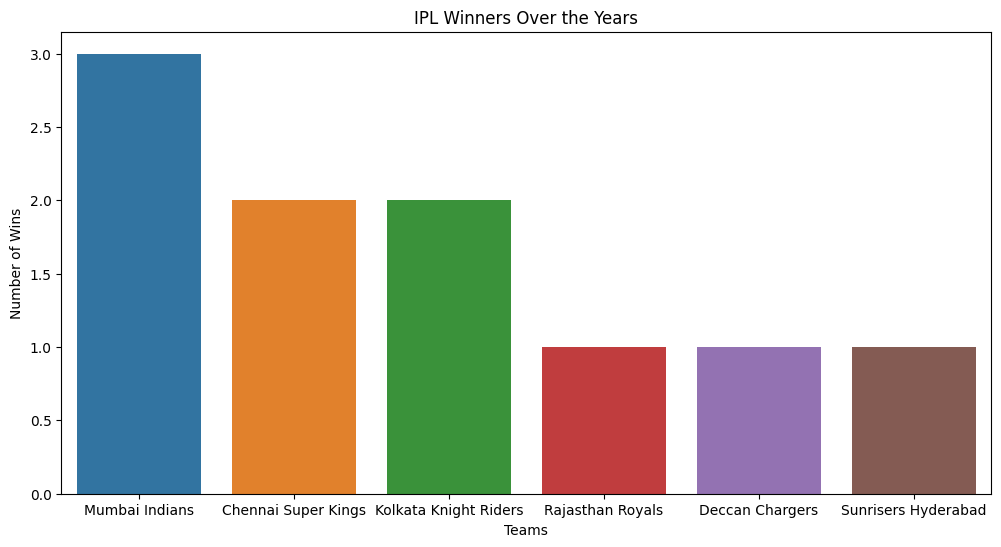

In [19]:
# Who has won the IPL tournament?
final_matches = matches_df.groupby('season').tail(1)

ipl_winners = final_matches['winner'].value_counts()

plt.figure(figsize=(12, 6))
sns.barplot(x=ipl_winners.index, y=ipl_winners.values)
plt.title('IPL Winners Over the Years')
plt.xlabel('Teams')
plt.ylabel('Number of Wins')
plt.show()

In [20]:
# Which are the most and least consistent teams across all seasons?
consistency_scores = matches_df.groupby('winner')['season'].std().sort_values()

most_consistent_team = consistency_scores.idxmin()
least_consistent_team = consistency_scores.idxmax()

print(f"The most consistent team across all seasons is: {most_consistent_team}")
print(f"The least consistent team across all seasons is: {least_consistent_team}")


The most consistent team across all seasons is: Kochi Tuskers Kerala
The least consistent team across all seasons is: Delhi Daredevils


In [21]:
# What has been the biggest margin of victory in terms of runs in the IPL?

biggest_margin_by_runs = matches_df.loc[matches_df['win_by_runs'].idxmax()]

print("Biggest Margin of Victory in Terms of Runs:")
print(biggest_margin_by_runs[['season', 'team1', 'team2', 'winner', 'win_by_runs']])

Biggest Margin of Victory in Terms of Runs:
season                     2017
team1            Mumbai Indians
team2          Delhi Daredevils
winner           Mumbai Indians
win_by_runs                 146
Name: 43, dtype: object


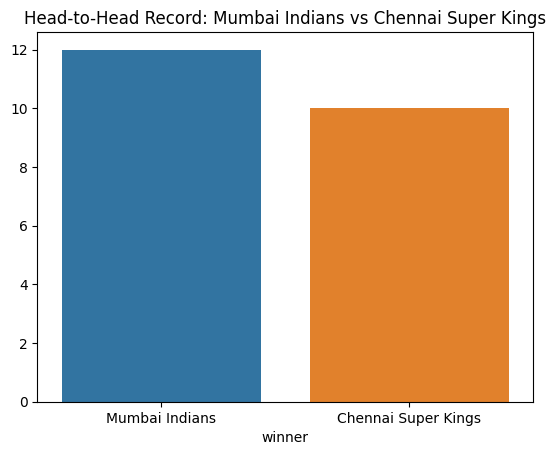

In [22]:
# Mumbai and Chennai are the two most successful teams so far. Which team leads in the head-to-head record?
mivscsk = matches_df[((matches_df['team1'] == 'Mumbai Indians') & (matches_df['team2'] == 'Chennai Super Kings')) |
                    ((matches_df['team1'] == 'Chennai Super Kings') & (matches_df['team2'] == 'Mumbai Indians'))]['winner'].value_counts()
sns.barplot(x=mivscsk.index, y=mivscsk.values)
plt.title('Head-to-Head Record: Mumbai Indians vs Chennai Super Kings')
plt.show()

In [23]:
# Total runs scored across the seasons.
season_data=ipl_matches[['id','season']].merge(ipl_deliveries, left_on = 'id', right_on = 'match_id', how = 'left').drop('id', axis = 1)
season_data.head()

,season,match_id,inning,batting_team,bowling_team,over,ball,batsman,non_striker,bowler,...,bye_runs,legbye_runs,noball_runs,penalty_runs,batsman_runs,extra_runs,total_runs,player_dismissed,dismissal_kind,fielder
0,2017,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,1,DA Warner,S Dhawan,TS Mills,...,0,0,0,0,0,0,0,NaN,NaN,NaN
1,2017,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,2,DA Warner,S Dhawan,TS Mills,...,0,0,0,0,0,0,0,NaN,NaN,NaN
2,2017,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,3,DA Warner,S Dhawan,TS Mills,...,0,0,0,0,4,0,4,NaN,NaN,NaN
3,2017,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,4,DA Warner,S Dhawan,TS Mills,...,0,0,0,0,0,0,0,NaN,NaN,NaN
4,2017,1,1,Sunrisers Hyderabad,Royal Challengers Bangalore,1,5,DA Warner,S Dhawan,TS Mills,...,0,0,0,0,0,2,2,NaN,NaN,NaN


In [24]:
# Total Runs Across the Seasons
season=season_data.groupby(['season'])['total_runs'].sum().reset_index()
p=season.set_index('season')
fig = px.line(p, x=p.index, y="total_runs")
fig.update_layout(title="Total Runs Across the Seasons ",
                  titlefont={'size': 26},template='simple_white'     
                  )
fig.show()

In [25]:
# Runs scored per match across seasons.
match_per_season=ipl_matches.groupby(['season'])['id'].count().reset_index().rename(columns={'id':'matches'})
runs_per_season=pd.concat([match_per_season,season.iloc[:,1]],axis=1)
runs_per_season['Runs scored per match']=runs_per_season['total_runs']/runs_per_season['matches']
runs_per_season.set_index('season',inplace=True)
runs_per_season.style.background_gradient(cmap='PuBu',subset=['Runs scored per match'])

,matches,total_runs,Runs scored per match
season,,,
2008,58,17937,309.258621
2009,57,16353,286.894737
2010,60,18883,314.716667
2011,73,21154,289.780822
2012,74,22453,303.418919
2013,76,22602,297.394737
2014,60,18931,315.516667
2015,59,18353,311.067797
2016,60,18862,314.366667


In [26]:
fig = px.line(runs_per_season, x=runs_per_season.index, y="Runs scored per match")
fig.update_layout(title="Runs scored per match across seasons",
                  titlefont={'size': 26},template='simple_white'     
                  )
fig.show()

In [27]:
# Decision made after winning the toss.
temp_series = ipl_matches.toss_decision.value_counts()
labels = (np.array(temp_series.index))
values = (np.array((temp_series / temp_series.sum())*100))
colors = ['turquoise', 'crimson']
fig = go.Figure(data=[go.Pie(labels=labels,
                             values=values,hole=.3)])
fig.update_traces(hoverinfo='label+percent', textinfo='label+percent', textfont_size=20,
                  marker=dict(colors=colors, line=dict(color='#000000', width=3)))
fig.update_layout(title="Toss decision percentage",
                  titlefont={'size': 30},
                  )
fig.show()

In [28]:
# Winning toss implies winning game ?
ipl_matches['toss_win_game_win'] = np.where((ipl_matches.toss_winner == ipl_matches.winner),'Yes','No')
ipl_matches.head()

,id,season,city,date,team1,team2,toss_winner,toss_decision,result,dl_applied,winner,win_by_runs,win_by_wickets,player_of_match,venue,umpire1,umpire2,umpire3,toss_win_game_win
0,1,2017,Hyderabad,2017-04-05,Sunrisers Hyderabad,Royal Challengers Bangalore,Royal Challengers Bangalore,field,normal,0,Sunrisers Hyderabad,35,0,Yuvraj Singh,"Rajiv Gandhi International Stadium, Uppal",AY Dandekar,NJ Llong,NaN,No
1,2,2017,Pune,2017-04-06,Mumbai Indians,Rising Pune Supergiant,Rising Pune Supergiant,field,normal,0,Rising Pune Supergiant,0,7,SPD Smith,Maharashtra Cricket Association Stadium,A Nand Kishore,S Ravi,NaN,Yes
2,3,2017,Rajkot,2017-04-07,Gujarat Lions,Kolkata Knight Riders,Kolkata Knight Riders,field,normal,0,Kolkata Knight Riders,0,10,CA Lynn,Saurashtra Cricket Association Stadium,Nitin Menon,CK Nandan,NaN,Yes
3,4,2017,Indore,2017-04-08,Rising Pune Supergiant,Kings XI Punjab,Kings XI Punjab,field,normal,0,Kings XI Punjab,0,6,GJ Maxwell,Holkar Cricket Stadium,AK Chaudhary,C Shamshuddin,NaN,Yes
4,5,2017,Bangalore,2017-04-08,Royal Challengers Bangalore,Delhi Daredevils,Royal Challengers Bangalore,bat,normal,0,Royal Challengers Bangalore,15,0,KM Jadhav,M Chinnaswamy Stadium,NaN,NaN,NaN,Yes


In [29]:
labels =["Yes",'No']
values = ipl_matches['toss_win_game_win'].value_counts()
colors = ['turquoise', 'crimson']
fig = go.Figure(data=[go.Pie(labels=labels,
                             values=values,hole=.3)])
fig.update_traces(hoverinfo='label+percent', textinfo='label+percent', textfont_size=20,
                  marker=dict(colors=colors, line=dict(color='#000000', width=3)))
fig.update_layout(title="Winning toss implies winning macthes?",
                  titlefont={'size': 30},
                  )
fig.show()

In [30]:
matches_played_byteams=pd.concat([ipl_matches['team1'],ipl_matches['team2']],axis=1)
wins=pd.DataFrame(ipl_matches['winner'].value_counts()).reset_index()
wins.columns=['Team Name','Wins']
teams=(matches_played_byteams['team1'].value_counts()+matches_played_byteams['team2'].value_counts()).reset_index()
teams.columns=['Team Name','Total Matches played']
played=teams.merge(wins,left_on='Team Name',right_on='Team Name',how='inner')
played['% Win']=(played['Wins']/played['Total Matches played'])*100
played.sort_values(by=['% Win'],ascending=False).reset_index().drop('index',axis=1).style.background_gradient(cmap='PuBu',subset=['% Win'])

,Team Name,Total Matches played,Wins,% Win
0,Rising Pune Supergiant,16,10,62.500000
1,Chennai Super Kings,131,79,60.305344
2,Mumbai Indians,157,92,58.598726
3,Sunrisers Hyderabad,76,42,55.263158
4,Rajasthan Royals,118,63,53.389831
5,Kolkata Knight Riders,148,77,52.027027
6,Royal Challengers Bangalore,152,73,48.026316
7,Kings XI Punjab,148,70,47.297297
8,Gujarat Lions,30,13,43.333333
9,Kochi Tuskers Kerala,14,6,42.857143


In [31]:
# Most number of wins.
colors = ['turquoise',] * 15
colors[7] = 'crimson'
fig=px.bar(x=played['Team Name'],y=played['Wins'],labels=dict(x="Team Name",y="Count"),)
fig.update_layout(title="Total Win by teams",
                  titlefont={'size': 26},template='simple_white'     
                  )
fig.update_traces(marker_line_color='black',
                  marker_line_width=2.5, opacity=1,marker_color=colors)
fig.show()

In [32]:
# Lucky Venues for a team.
def lucky(match_data,team_name):
    return match_data[match_data['winner']==team_name]['venue'].value_counts().nlargest(10)
mi=lucky(ipl_matches,'Mumbai Indians')
values = mi
labels=mi.index
colors = ['turquoise', 'crimson']
fig = go.Figure(data=[go.Pie(labels=labels,values=values,hole=.3)])
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=20,
                  marker=dict(colors=colors, line=dict(color='#000000', width=3)))
fig.update_layout(title="Wins at different Venues for MI:",
                  titlefont={'size': 30},
                  )
fig.show()

In [33]:
rcb=lucky(ipl_matches,'Royal Challengers Bangalore')
values = rcb
labels=rcb.index
colors = ['turquoise', 'crimson']
fig = go.Figure(data=[go.Pie(labels=labels,values=values,hole=.3)])
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=20,
                  marker=dict(colors=colors, line=dict(color='#000000', width=3)))
fig.update_layout(title="Wins at different Venues for RCB:",
                  titlefont={'size': 30},
                  )
fig.show()

In [34]:
csk=lucky(ipl_matches,'Chennai Super Kings')
values = csk
labels=csk.index
colors = ['turquoise', 'crimson']
fig = go.Figure(data=[go.Pie(labels=labels,values=values,hole=.3)])
fig.update_traces(hoverinfo='label+percent', textinfo='value', textfont_size=20,
                  marker=dict(colors=colors, line=dict(color='#000000', width=3)))
fig.update_layout(title="Wins at different Venues for CSK:",
                  titlefont={'size': 30},
                  )
fig.show()


In [35]:
# Innings wise comparision.
runs=ipl_deliveries.groupby(['match_id','inning','batting_team'])[['total_runs']].sum().reset_index()
runs.drop('match_id',axis=1,inplace=True)
runs.head()

,inning,batting_team,total_runs
0,1,Sunrisers Hyderabad,207
1,2,Royal Challengers Bangalore,172
2,1,Mumbai Indians,184
3,2,Rising Pune Supergiant,187
4,1,Gujarat Lions,183


In [36]:
inning1=runs[runs['inning']==1]
inning2=runs[runs['inning']==2]

In [37]:
# Batting First.
fig = px.box(y='total_runs',x='batting_team',data_frame=inning1,color='batting_team')

fig.update_layout(title="Batting First",
                  titlefont={'size': 26},template='simple_white'
                  )
fig.show()

In [38]:
# Batting second.
fig = px.box(y='total_runs',x='batting_team',data_frame=inning2,color='batting_team')

fig.update_layout(title="Batting Second",
                  titlefont={'size': 26},template='simple_white'
                  )
fig.show()

**My Analaysis Completes Here.**
I hope I was able to represent the IPL dataset in the much best way possible. 
Please DO UPVOTE if you like my Work.
***Thank You***